In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
columns = [
    'ID','Diagnosis',
    'radius1','texture1','perimeter1','area1','smoothness1','compactness1','concavity1','concave_points1','symmetry1','fractal_dimension1',
    'radius2','texture2','perimeter2','area2','smoothness2','compactness2','concavity2','concave_points2','symmetry2','fractal_dimension2',
    'radius3','texture3','perimeter3','area3','smoothness3','compactness3','concavity3','concave_points3','symmetry3','fractal_dimension3',
]
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv('wdbc.data',header= None, names= columns)

print(df.head())


         ID Diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0    842302         M    17.99     10.38      122.80  1001.0      0.11840   
1    842517         M    20.57     17.77      132.90  1326.0      0.08474   
2  84300903         M    19.69     21.25      130.00  1203.0      0.10960   
3  84348301         M    11.42     20.38       77.58   386.1      0.14250   
4  84358402         M    20.29     14.34      135.10  1297.0      0.10030   

   compactness1  concavity1  concave_points1  ...  radius3  texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3  \
0      184.60  2019.0  

In [3]:
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])
print(df.head())

         ID  Diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0    842302          1    17.99     10.38      122.80  1001.0      0.11840   
1    842517          1    20.57     17.77      132.90  1326.0      0.08474   
2  84300903          1    19.69     21.25      130.00  1203.0      0.10960   
3  84348301          1    11.42     20.38       77.58   386.1      0.14250   
4  84358402          1    20.29     14.34      135.10  1297.0      0.10030   

   compactness1  concavity1  concave_points1  ...  radius3  texture3  \
0       0.27760      0.3001          0.14710  ...    25.38     17.33   
1       0.07864      0.0869          0.07017  ...    24.99     23.41   
2       0.15990      0.1974          0.12790  ...    23.57     25.53   
3       0.28390      0.2414          0.10520  ...    14.91     26.50   
4       0.13280      0.1980          0.10430  ...    22.54     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3  \
0      184.60  20

In [4]:
print(df.shape)
print(df.info())
print(df.describe())


(569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  569 non-null    int64  
 1   Diagnosis           569 non-null    int64  
 2   radius1             569 non-null    float64
 3   texture1            569 non-null    float64
 4   perimeter1          569 non-null    float64
 5   area1               569 non-null    float64
 6   smoothness1         569 non-null    float64
 7   compactness1        569 non-null    float64
 8   concavity1          569 non-null    float64
 9   concave_points1     569 non-null    float64
 10  symmetry1           569 non-null    float64
 11  fractal_dimension1  569 non-null    float64
 12  radius2             569 non-null    float64
 13  texture2            569 non-null    float64
 14  perimeter2          569 non-null    float64
 15  area2               569 non-null    float64
 16

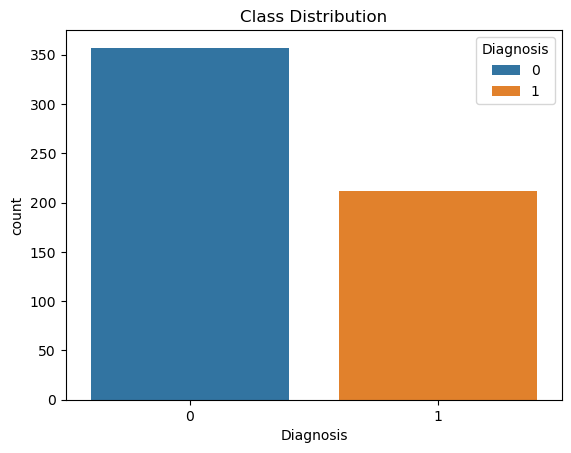

In [5]:

#df['Diagnosis'].value_counts(normalize=True) * 100
sns.countplot(x="Diagnosis",data=df,hue='Diagnosis')
plt.title("Class Distribution")
plt.show()

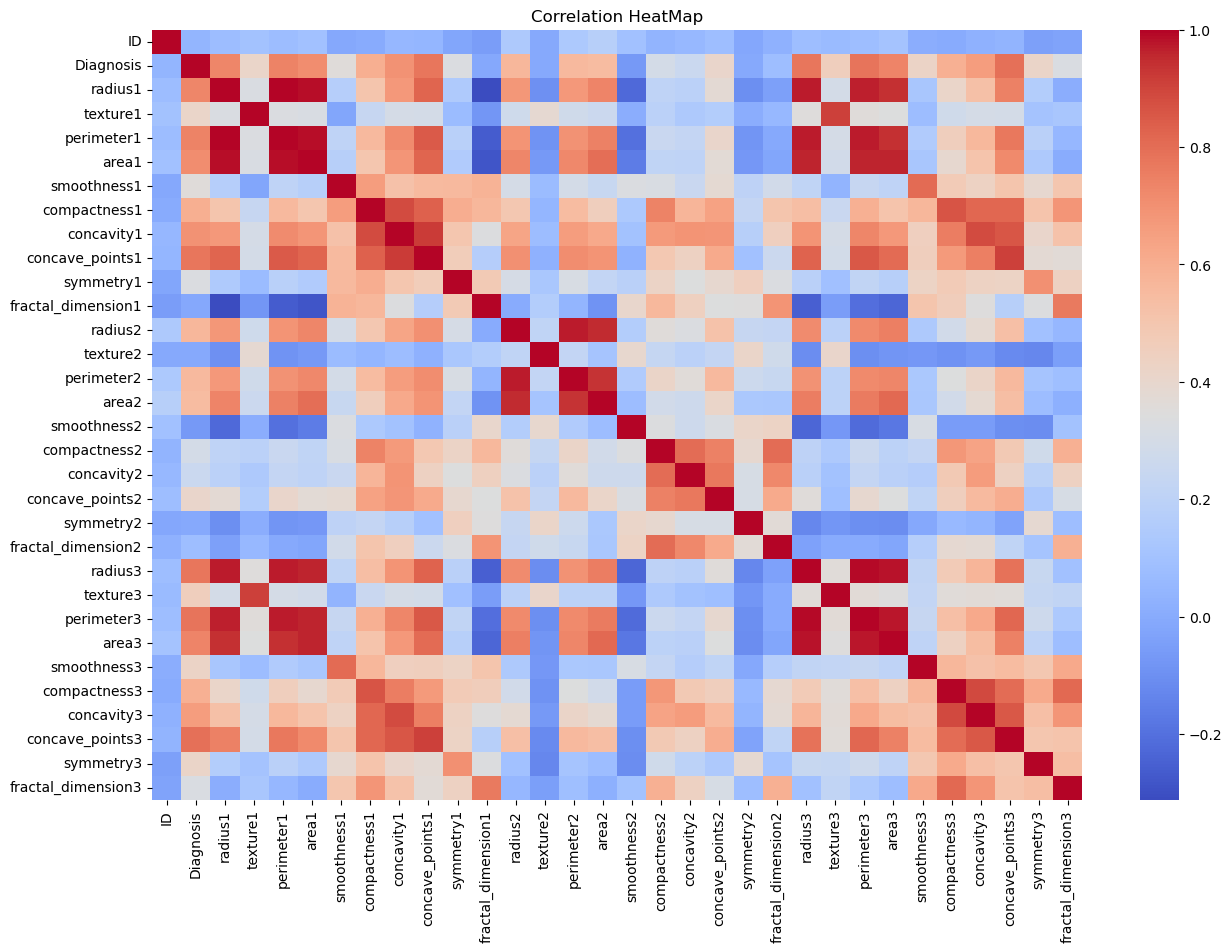

In [6]:
corr = df.corr()

plt.figure(figsize=(15,10))

sns.heatmap(corr,cmap="coolwarm")
plt.title("Correlation HeatMap")
plt.show()


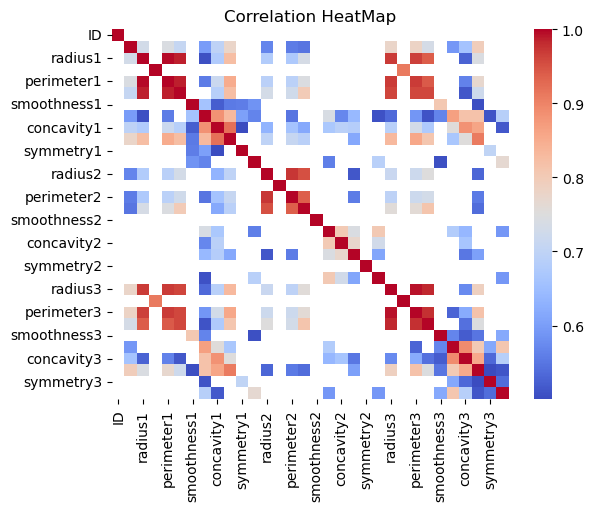

In [7]:
filtered_corr= corr.copy()
filtered_corr[(corr <0.50) & (corr > -0.50)] = np.nan
sns.heatmap(filtered_corr,cmap="coolwarm")
plt.title("Correlation HeatMap")
plt.show()

In [8]:
X = df.drop(["ID", "Diagnosis"], axis=1)
Y = df["Diagnosis"]
X_train , X_test,Y_train, Y_test  = train_test_split(
    X,Y,test_size=0.2,random_state=42
)


In [9]:
X_train,X_test, Y_train,Y_test = train_test_split(
    X,Y , test_size=0.2,random_state=42
)

baggingModel = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    max_samples=0.8,
    random_state=42
)

baggingModel.fit(X_train,Y_train)



BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.8,
                  n_estimators=50, random_state=42)

In [10]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

ada_model = AdaBoostClassifier(
    n_estimators=20,
    learning_rate=1.0,
    random_state=42

)

gb_model = GradientBoostingClassifier(
    n_estimators=20,
    learning_rate=0.2,
    max_depth=4,
    random_state=42
)

ada_model.fit(X_train,Y_train)
gb_model.fit(X_train,Y_train)


GradientBoostingClassifier(learning_rate=0.2, max_depth=4, n_estimators=20,
                           random_state=42)

In [11]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('dt', DecisionTreeClassifier()),
    ('ada', AdaBoostClassifier(n_estimators=30)),
    ('gb', GradientBoostingClassifier(n_estimators=50)),
    
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
)

stack_model.fit(X_train,Y_train)


StackingClassifier(estimators=[('dt', DecisionTreeClassifier()),
                               ('ada', AdaBoostClassifier(n_estimators=30)),
                               ('gb',
                                GradientBoostingClassifier(n_estimators=50))],
                   final_estimator=LogisticRegression())

In [12]:
param_grid = {
    'bagging': {
        'n_estimators': [10, 50, 100],
        'max_samples': [0.5, 0.8, 1.0]
    },
    'adaboost': {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1, 1]
    },
    'gradientboost': {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    }
}

In [13]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42
)

bagging_params = {
    "n_estimators": [10, 50, 100],
    "max_samples": [0.5, 0.7, 1.0],
    "max_features": [0.5, 0.7, 1.0]
}

bagging_grid = GridSearchCV(
    bagging,
    bagging_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

bagging_grid.fit(X_train, Y_train)

print("Best Bagging Params:", bagging_grid.best_params_)
best_bagging = bagging_grid.best_estimator_

Best Bagging Params: {'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 50}


In [14]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

ada = AdaBoostClassifier(random_state=42)

ada_params = {
    "n_estimators": [20, 50, 100],
    "learning_rate": [0.01, 0.1, 1.0]
}

ada_grid = GridSearchCV(ada, ada_params, cv=5, scoring="accuracy")
ada_grid.fit(X_train, Y_train)

best_ada = ada_grid.best_estimator_


gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 4, 5]
}

gb_grid = GridSearchCV(gb, gb_params, cv=5, scoring="accuracy")
gb_grid.fit(X_train, Y_train)

best_gb = gb_grid.best_estimator_

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))


In [16]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

stacking_model = StackingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier()),
    ('ada', AdaBoostClassifier(n_estimators=30)),
    ('gb', GradientBoostingClassifier(n_estimators=50)),
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stacking_model.fit(X_train, Y_train)


StackingClassifier(cv=5,
                   estimators=[('dt', DecisionTreeClassifier()),
                               ('ada', AdaBoostClassifier(n_estimators=30)),
                               ('gb',
                                GradientBoostingClassifier(n_estimators=50))],
                   final_estimator=LogisticRegression())

In [17]:
evaluate_model(best_bagging, X_test, Y_test)
evaluate_model(best_ada, X_test, Y_test)
evaluate_model(best_gb, X_test, Y_test)
evaluate_model(stacking_model, X_test, Y_test)

Accuracy: 0.9649122807017544
Precision: 0.975609756097561
Recall: 0.9302325581395349
F1 Score: 0.9523809523809523
Accuracy: 0.9649122807017544
Precision: 0.975609756097561
Recall: 0.9302325581395349
F1 Score: 0.9523809523809523
Accuracy: 0.956140350877193
Precision: 0.9523809523809523
Recall: 0.9302325581395349
F1 Score: 0.9411764705882353
Accuracy: 0.956140350877193
Precision: 0.9523809523809523
Recall: 0.9302325581395349
F1 Score: 0.9411764705882353


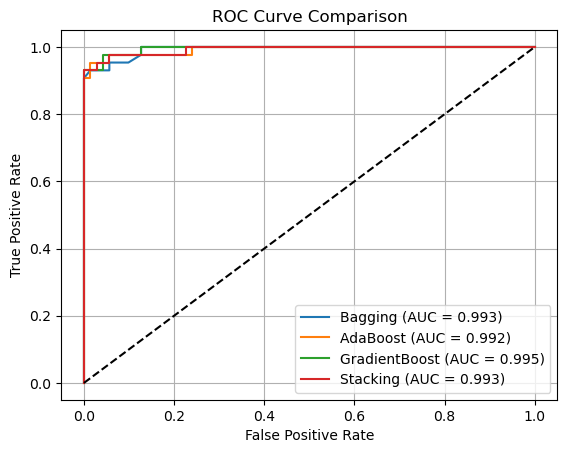

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_combined_roc(models, model_names, X_test, y_test):
    plt.figure()

    for model, name in zip(models, model_names):
        y_prob = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

    
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.grid()
    plt.show()

models = [best_bagging, best_ada, best_gb, stacking_model]
model_names = ["Bagging", "AdaBoost", "GradientBoost", "Stacking"]

plot_combined_roc(models, model_names, X_test, Y_test)

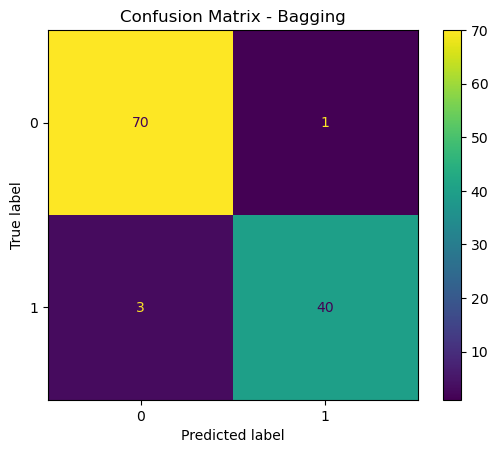

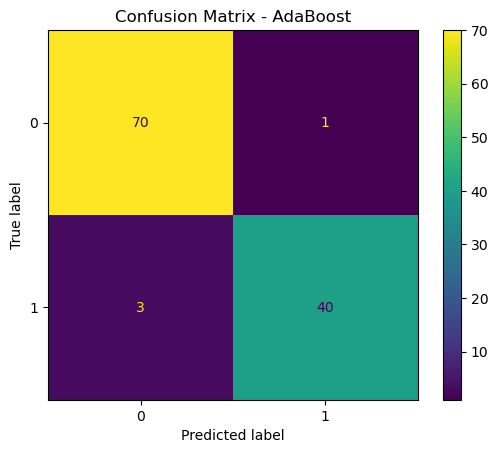

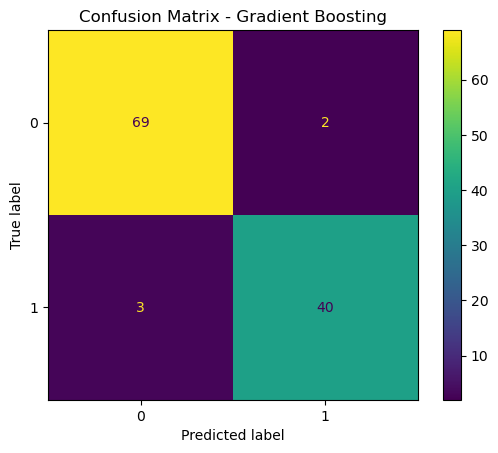

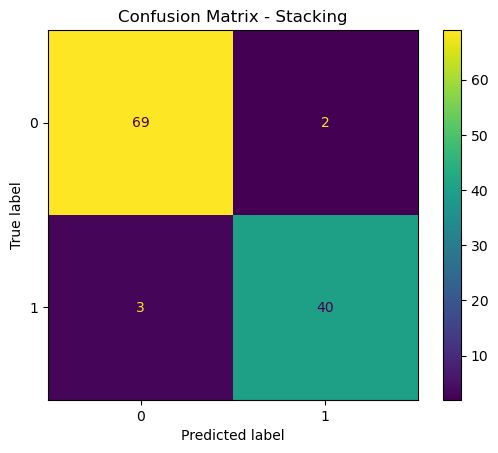

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, model_name, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


# Call for all models
plot_confusion_matrix(best_bagging, "Bagging", X_test, Y_test)
plot_confusion_matrix(best_ada, "AdaBoost", X_test, Y_test)
plot_confusion_matrix(best_gb, "Gradient Boosting", X_test, Y_test)
plot_confusion_matrix(stacking_model, "Stacking", X_test, Y_test)

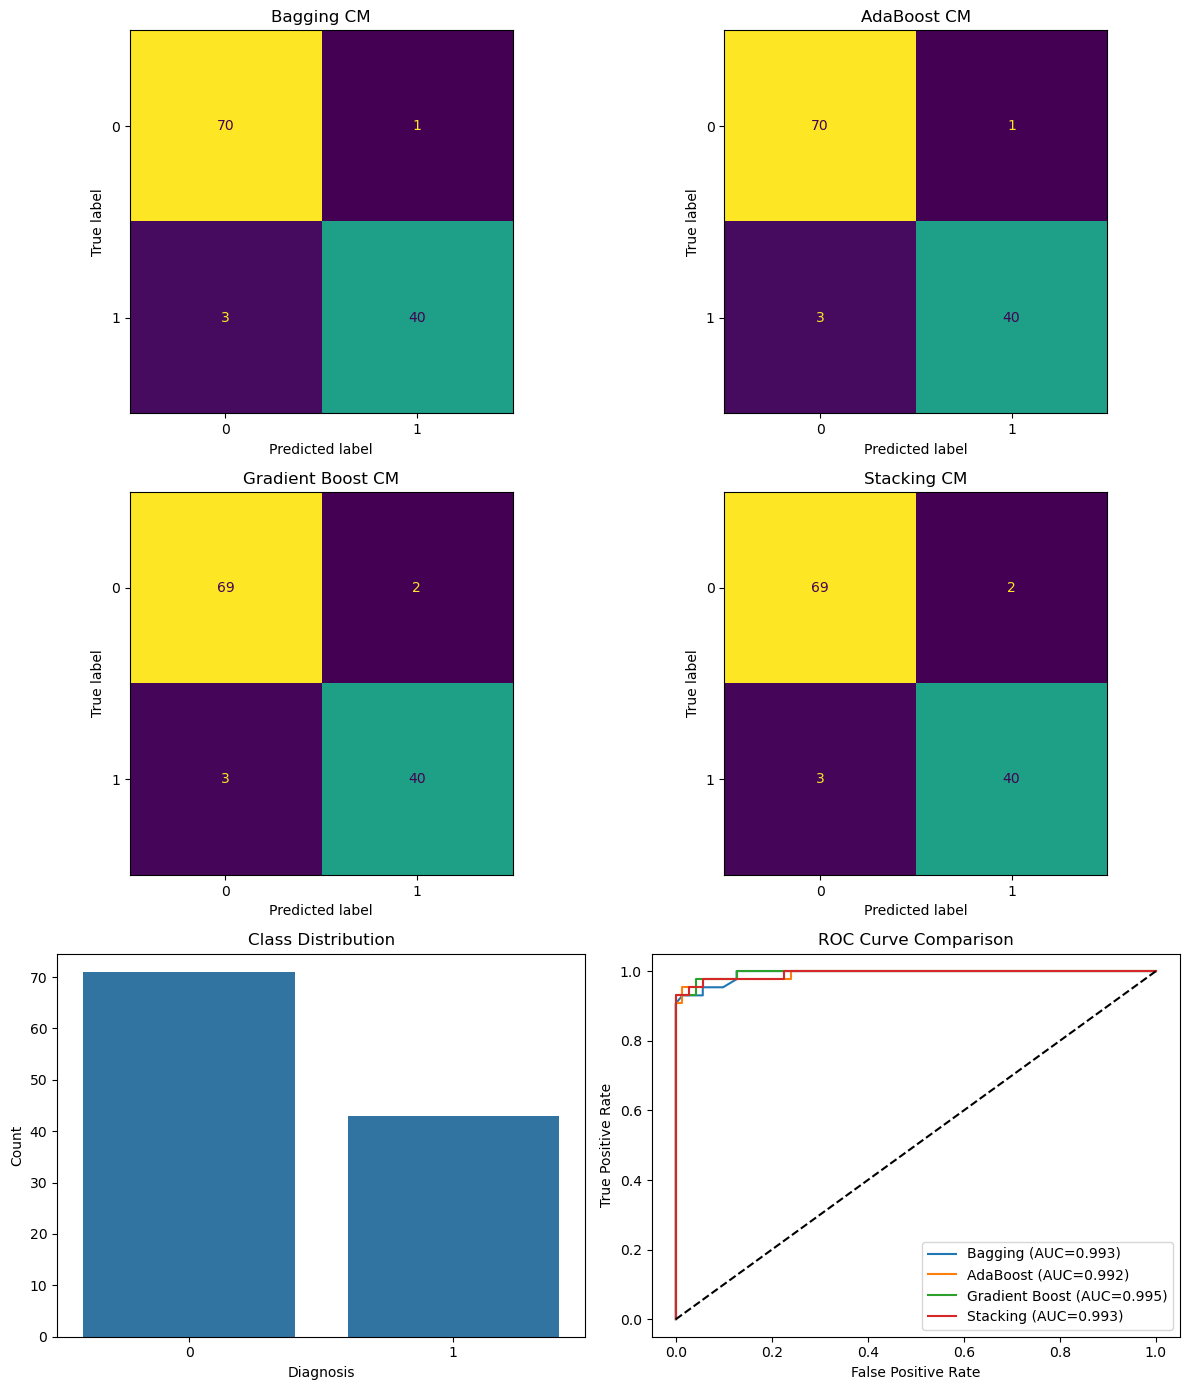

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Models
models = [
    (best_bagging, "Bagging"),
    (best_ada, "AdaBoost"),
    (best_gb, "Gradient Boost"),
    (stacking_model, "Stacking")
]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

# ---------------------------
# 🔹 Top 4: Confusion Matrices
# ---------------------------
for ax, (model, name) in zip(axes[:2].flatten(), models):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(Y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} CM")

# ---------------------------
# 🔹 Bottom Left: Class Distribution
# ---------------------------
sns.countplot(x=Y_test, ax=axes[2, 0])
axes[2, 0].set_title("Class Distribution")
axes[2, 0].set_xlabel("Diagnosis")
axes[2, 0].set_ylabel("Count")

# ---------------------------
# 🔹 Bottom Right: ROC Curve (Combined)
# ---------------------------
for model, name in models:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    axes[2, 1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

axes[2, 1].plot([0, 1], [0, 1], 'k--')
axes[2, 1].set_title("ROC Curve Comparison")
axes[2, 1].set_xlabel("False Positive Rate")
axes[2, 1].set_ylabel("True Positive Rate")
axes[2, 1].legend()

# ---------------------------
# Final Layout
# ---------------------------
plt.tight_layout()
plt.savefig("totalplt.jpg")
plt.show()